# CS6102 - Python for Data Analytics

## Predicting Air Quality Index

#### Aakash A 
#### 25MSP3019

#### Aim: To apply predictive analytics on the air quality dataset in order to forecast pollution levels (e.g., PM2.5, PM10, NO₂) across different cities and time periods, enabling better understanding of trends and supporting data-driven decisions for air quality management.

#### Dataset Link: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india

#### Dataset Description: The dataset contains air quality and pollutant concentration data across different years. It includes key pollutants such as PM2.5, PM10, NO, NO₂, NOx, NH₃, CO, SO₂, O₃, Benzene, Toluene, and Xylene, along with the Year of measurement. The target variable is the Air Quality Index (AQI), which provides an overall measure of air pollution levels.

## 1. Load Data

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [77]:
data = pd.read_csv("city_day.csv")
df = pd.DataFrame(data)

In [78]:
## Displaying First Five rows
df.head(5)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [79]:
## Displaying Last Five rows
df.tail(5)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
18260,Delhi,2024-12-31,371.2,61.7,14.6,130.7,159.1,45.9,7.02,76.4,40.0,7.99,5.71,0.36,61.5,Poor
18261,Mumbai,2024-12-31,180.2,259.3,181.9,50.7,135.7,22.4,8.85,12.2,147.3,13.93,7.15,2.08,312.7,Satisfactory
18262,Chennai,2024-12-31,188.6,434.4,68.8,126.1,142.7,47.0,8.30,50.2,128.6,6.98,6.71,2.10,366.1,Good
18263,Kolkata,2024-12-31,343.0,458.6,106.7,108.3,137.8,22.6,2.11,71.4,175.8,4.12,11.68,0.88,397.5,Good
18264,Bangalore,2024-12-31,121.9,100.0,37.7,118.5,224.8,32.6,9.89,16.9,62.6,15.21,4.98,7.06,309.5,Very Poor


In [80]:
## Display the no. of rows and columns
df.shape

(18265, 16)

In [81]:
## Info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


In [82]:
## Describing the dataset

df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


## 2. Preprocessing

In [83]:
## Checking for duplicates

duplicate = df[df.duplicated()]

print("No. of Duplicates: ",duplicate.shape[0])

No. of Duplicates:  0


In [84]:
## Checking for null values in the dataset

df.isnull().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

## 3. Exploratory Data Analytics

<Axes: xlabel='AQI', ylabel='Density'>

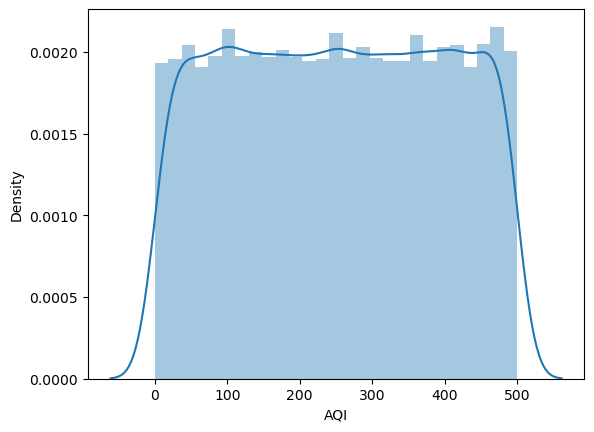

In [85]:
##-- Distribution of target variable
sns.distplot(df['AQI'])  ##KDE plot and Histogram together

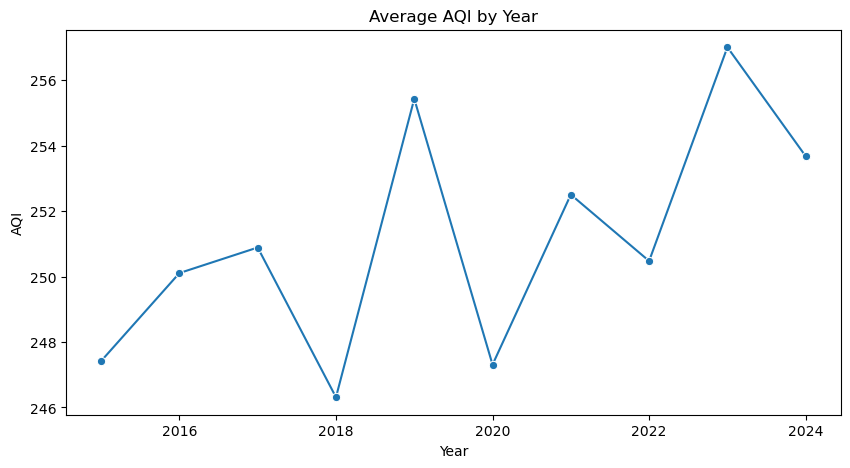

In [86]:
## Yearly AQI Trend using Line Plot
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['Year'] = df['Datetime'].dt.year

yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o')
plt.title("Average AQI by Year")
plt.ylabel("AQI")
plt.xlabel("Year")
plt.show()

<Axes: title={'center': 'Distribution of Average AQI in Each City (Year-wise)'}, xlabel='City', ylabel='AQI'>

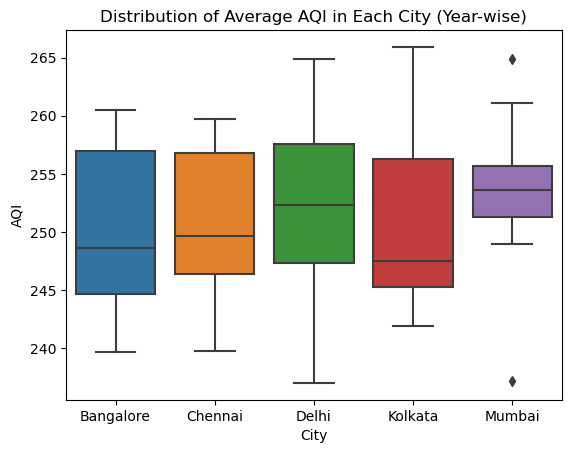

In [87]:
## Average AQI in each city over the years

city_aqi = df.groupby(['City', 'Year'])['AQI'].mean().reset_index()

plt.title("Distribution of Average AQI in Each City (Year-wise)")
plt.ylabel("Average AQI")
plt.xlabel("City")
sns.boxplot(data=city_aqi, x = 'City', y = 'AQI')

Text(0.5, 1.0, 'Correlation of Pollutants with AQI')

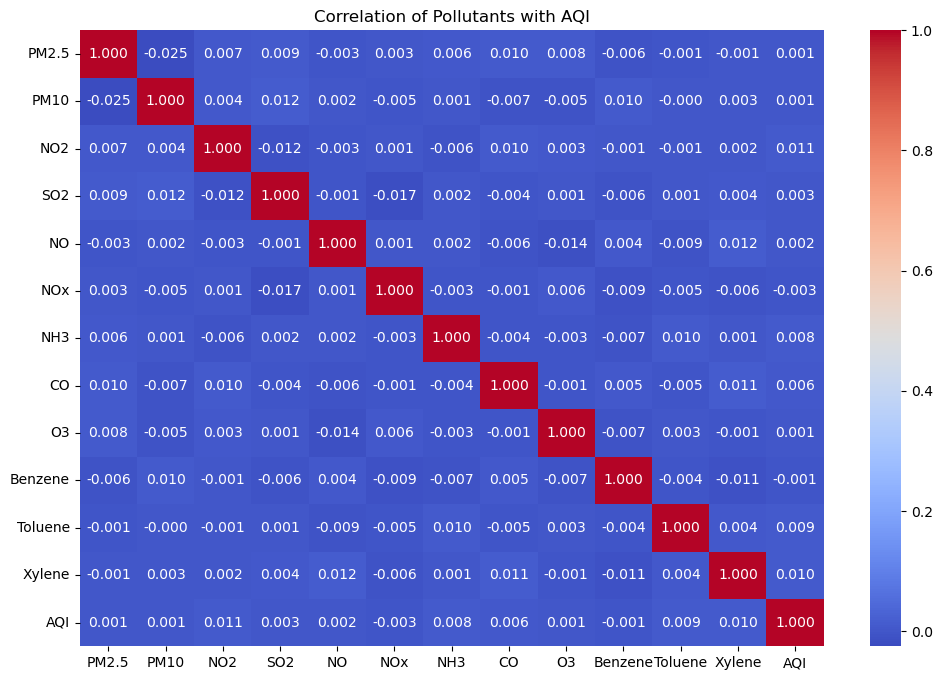

In [88]:
## Heatmap for Pollutants and AQI
cols = ['PM2.5','PM10','NO2','SO2','NO','NOx','NH3','CO','O3','Benzene','Toluene','Xylene','AQI']
plt.figure(figsize=(12,8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm',fmt=".3f")
plt.title("Correlation of Pollutants with AQI")

## 4. Connecting to SQLite3

In [89]:
import sqlite3

In [90]:
try:
    sqliteConnection = sqlite3.connect('Project.db')
    cursor = sqliteConnection.cursor()
    data.to_sql('Air_Quality_Index',sqliteConnection,index=True,if_exists='replace')
    print("Succesfully established connection")
except sqlite3.Error as error:
    print("Error while working with sqlite",error)
finally:
    if sqliteConnection:
        sqliteConnection.close()
        print("Sqlite connection is closed")

Succesfully established connection
Sqlite connection is closed


![SqliteTable](sqlite31.png)

![SqliteTable](sqlite32.png)

## 5. Prediction of AQI

In [91]:
## MultiLinear Regression and Random Tree regressor

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

### Multi linear regression

In [92]:
x = df.drop(['AQI','Datetime','AQI_Bucket','City'],axis = 1) ## x should be a dataframe
y = data['AQI']  ## y should be a list

In [93]:
## split data into train and test
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=100)

Intercept:  -397.1156574158289
Coefficient:  [('PM2.5', 0.009330967892132704), ('PM10', -0.005127899004927881), ('NO', 0.01457739672258997), ('NO2', 0.042993997911660975), ('NOx', -0.01009146327952542), ('NH3', 0.05065536601274234), ('CO', 0.712236859716846), ('SO2', 0.026919990802551377), ('O3', 0.020935611515408882), ('Benzene', 0.13741900827292414), ('Toluene', 0.10449905655822872), ('Xylene', 0.4417740526975619), ('Year', 0.3118522708134377)]
       Actual values  Predicted values
14378          230.2        250.449570
6197           429.6        243.572146
9967            52.1        248.683153
13037          283.0        249.642649
16447          216.0        254.753832
7701           319.6        245.618664
5669           235.6        246.701049
9667           399.7        254.926522
Mean Absolute Error: 125.50126516904518
Mean Squared Error: 20859.032497375516
Root Mean Square Error: 144.42656437572526
R² Score: -0.001665767567766041


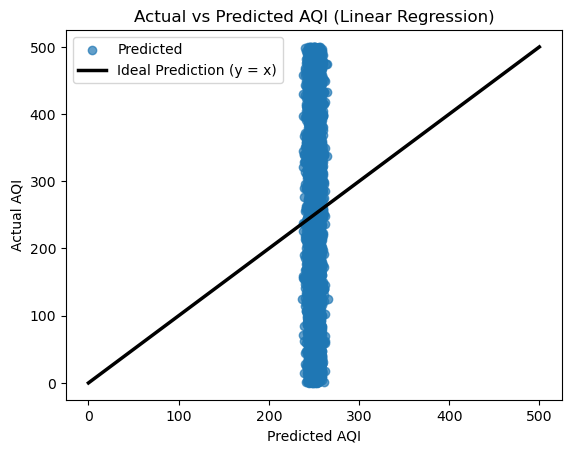

In [94]:
class Linear:
    def lreg(self):
        mlr = LinearRegression()
        mlr.fit(x_train,y_train)
        print("Intercept: ",mlr.intercept_)
        print("Coefficient: ",list(zip(x_train.columns,mlr.coef_)))
        y_pred_mlr = mlr.predict(x_test)
        ##-- Compare actual and predicted values
        mlr_diff = pd.DataFrame({'Actual values':y_test,'Predicted values':y_pred_mlr})
        print(mlr_diff.head(8))
        meanAbErr = metrics.mean_absolute_error(y_test,y_pred_mlr)
        meanSqErr = metrics.mean_squared_error(y_test,y_pred_mlr)
        rootMeanSqErr = np.sqrt(metrics.mean_squared_error(y_test,y_pred_mlr))
        r2 = r2_score(y_test, y_pred_mlr)
        print("Mean Absolute Error:",meanAbErr)
        print("Mean Squared Error:",meanSqErr)
        print("Root Mean Square Error:",rootMeanSqErr)
        print("R² Score:", r2)
        plt.scatter(mlr.predict(x_test), y_test, label="Predicted", alpha=0.7)
        x = np.linspace(min(y_test), max(y_test), 100)
        plt.plot(x, x, color='black', lw=2.5, label="Ideal Prediction (y = x)")
        plt.xlabel("Predicted AQI")
        plt.ylabel("Actual AQI")
        plt.legend()
        plt.title("Actual vs Predicted AQI (Linear Regression)")
        plt.show()
        

l=Linear()
l.lreg()

### Single Linear Regression using PM2.5

In [96]:
x_l = df.drop(['AQI','Datetime','AQI_Bucket','City','PM10','NO2','SO2','NO','NOx','NH3','CO','O3','Benzene','Toluene','Xylene','Year'],axis = 1) ## x should be a dataframe
y_l = data['AQI']  ## y should be a list

In [97]:
## split data into train and test
x_train, x_test, y_train, y_test = train_test_split(x_l,y_l,test_size=0.2,random_state=100)

Intercept:  249.45662178545288
Coefficient:  [('PM2.5', 0.0022726268625404187)]
       Actual values  Predicted values
14378          230.2        250.162272
6197           429.6        250.191135
9967            52.1        250.110457
13037          283.0        250.030460
16447          216.0        250.050232
7701           319.6        250.259314
5669           235.6        250.507484
9667           399.7        250.392035
Mean Absolute Error: 126.34713392839717
Mean Squared Error: 21067.523526530516
Root Mean Square Error: 145.14655878294366
R² Score: -0.0014314013615417398


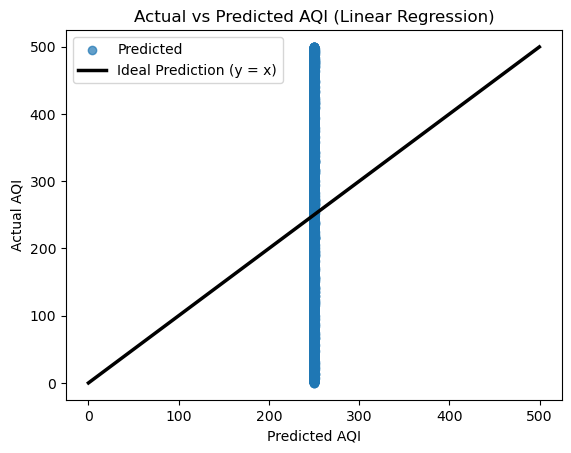

In [98]:
class SLinear:
    def slreg(self):
        slr = LinearRegression()
        slr.fit(x_train,y_train)
        print("Intercept: ",slr.intercept_)
        print("Coefficient: ",list(zip(x_train.columns,slr.coef_)))
        y_pred_slr = slr.predict(x_test)
        ##-- Compare actual and predicted values
        slr_diff = pd.DataFrame({'Actual values':y_test,'Predicted values':y_pred_slr})
        print(slr_diff.head(8))
        meanAbErr = metrics.mean_absolute_error(y_test,y_pred_slr)
        meanSqErr = metrics.mean_squared_error(y_test,y_pred_slr)
        rootMeanSqErr = np.sqrt(metrics.mean_squared_error(y_test,y_pred_slr))
        r2 = r2_score(y_test, y_pred_slr)
        print("Mean Absolute Error:",meanAbErr)
        print("Mean Squared Error:",meanSqErr)
        print("Root Mean Square Error:",rootMeanSqErr)
        print("R² Score:", r2)
        plt.scatter(slr.predict(x_test), y_test, label="Predicted", alpha=0.7)
        x = np.linspace(min(y_test), max(y_test), 100)
        plt.plot(x, x, color='black', lw=2.5, label="Ideal Prediction (y = x)")
        plt.xlabel("Predicted AQI")
        plt.ylabel("Actual AQI")
        plt.legend()
        plt.title("Actual vs Predicted AQI (Linear Regression)")
        plt.show()
        

sl=SLinear()
sl.slreg()

In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [100]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day

encoder = LabelEncoder()
df['City'] = encoder.fit_transform(df['City'])

target = "AQI"
features = [col for col in df.columns if col not in ['Datetime', target, 'AQI_Bucket']]

X = df[features]
y = df[target]

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=45)

In [101]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance:")
print("Mean Absolute Error::", mean_absolute_error(y_test, y_pred_rf))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Performance:
Mean Absolute Error:: 126.12630273722627
Root Mean Squared Error: 145.9168539138526
R2 Score: -0.018612889948295797


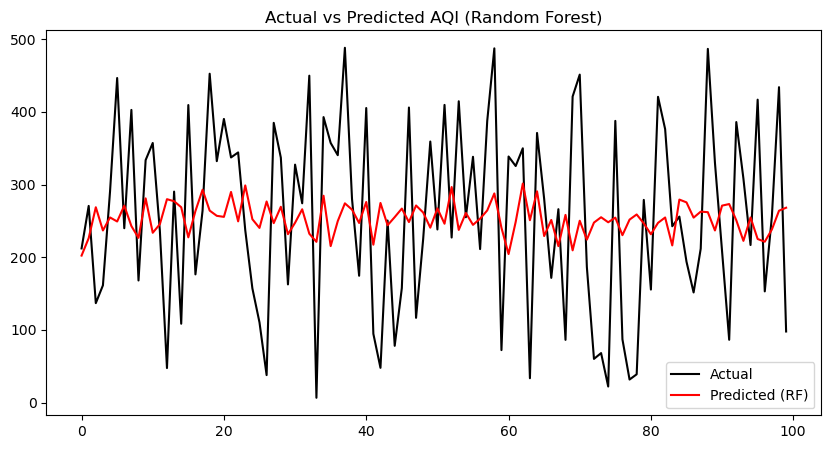

In [102]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color='black')
plt.plot(y_pred_rf[:100], label="Predicted (RF)", color='red')
plt.legend()
plt.title("Actual vs Predicted AQI (Random Forest)")
plt.show()

## 6. Model Comparision

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [104]:
dtree = DecisionTreeClassifier()
lr = LogisticRegression(max_iter=1000)
svm = SVC()

x = data.drop(['City','Datetime','AQI_Bucket'],axis=1)
y = data['AQI_Bucket']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

dtree.fit(x_train,y_train)
lr.fit(x_train,y_train)
svm.fit(x_train,y_train)

dtree_pred = dtree.predict(x_test)
lr_pred = lr.predict(x_test)
svm_pred = svm.predict(x_test)

In [105]:
dtree_accu = accuracy_score(y_test,dtree_pred)
lr_accu = accuracy_score(y_test,lr_pred)
svm_accu = accuracy_score(y_test,svm_pred)

print("Decision Tree Accuracy: ", dtree_accu)
print("Logistic Regression Accuracy: ", lr_accu)
print("SVM Accuracy: ", svm_accu)

Decision Tree Accuracy:  0.16725978647686832
Logistic Regression Accuracy:  0.16725978647686832
SVM Accuracy:  0.1749247194087052


## Conclusion

#### Linear Regression and Random Forest models struggled to predict AQI accurately. The errors remained high (MAE ~125, RMSE ~145), and the R² scores were negative, showing that neither model could explain the variation in AQI better than a simple average. This suggests that predicting AQI directly from the given dataset is difficult and may require additional features, or more advanced models. Overall, while the attempt demonstrates the process of applying machine learning to air quality prediction, the results highlight the need for further improvement.

#### The classification models (Decision Tree, Logistic Regression, and SVM) were applied to predict the AQI, but all performed poorly with accuracy around 16–17%. This shows that the current dataset and features are not sufficient for reliable AQI category prediction.